Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import re

##For Tamil

####Data- loading, tokenization, etc

In [4]:
train_data = pd.read_csv('/content/ai-gen product review detect - tam_train.csv')
test_data = pd.read_csv('/content/ai-gen product review detect - tam_test.csv')

print("Training Data:")
print(train_data.head())
print("\nTest Data:")
print(test_data.head())

Training Data:
                ID                                               DATA LABEL
0  TAM_HUAI_TR_001  இந்த சோப்பின் மணம் மிகவும் புத்துணர்ச்சியூட்டு...    AI
1  TAM_HUAI_TR_002   தோலை நன்கு சுத்தம் செய்ய இது மிகவும் சிறப்பானது.    AI
2  TAM_HUAI_TR_003  இதைப் பயன்படுத்திய பிறகு, தோல் மிக மென்மையாக உ...    AI
3  TAM_HUAI_TR_004  இந்த சோப்பில் இயற்கையான மூலப்பொருட்கள் பயன்படு...    AI
4  TAM_HUAI_TR_005        சிறிது சோப்பு போதும், அதிக நுரை உருவாகிறது.    AI

Test Data:
                ID                                               DATA
0  TAM_HUAI_TE_001  நான் அண்மையில் வாங்கிய ஒரு வாட்டர் பாட்டில் மி...
1  TAM_HUAI_TE_002                         அணிவதற்கு நன்றாக இருக்கும்
2  TAM_HUAI_TE_003                                  அதிக வாசனை வாந்தி
3  TAM_HUAI_TE_004                   அதிகமக பயன்பதுதினல் தலை சுட்ரும்
4  TAM_HUAI_TE_005                                    அழகாக இருக்கும்


In [5]:
print("Missing values in training data:")
print(train_data.isnull().sum())

Missing values in training data:
ID       0
DATA     0
LABEL    0
dtype: int64


In [6]:
print("Label distribution in training data:")
print(train_data['LABEL'].value_counts())

Label distribution in training data:
LABEL
AI       405
HUMAN    403
Name: count, dtype: int64


In [7]:
def tokenize_and_split(data, tokenizer, test_size=0.2, max_length=128, random_state=42):
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        data['DATA'],
        data['LABEL'].apply(lambda x: 1 if x == "AI" else 0),
        test_size=test_size,
        random_state=random_state
    )

    train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=max_length)
    val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=max_length)

    return {
        "train_encodings": train_encodings,
        "val_encodings": val_encodings,
        "train_labels": train_labels.tolist(),
        "val_labels": val_labels.tolist()
    }

###Model____1

####Model 1: ai4bharat/indic-bert

In [8]:
tokenizer = AutoTokenizer.from_pretrained('ai4bharat/indic-bert')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

In [9]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [10]:
class TamilDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

In [11]:
train_dataset = TamilDataset(train_encodings, list(train_labels))
val_dataset = TamilDataset(val_encodings, list(val_labels))

In [12]:
model = AutoModelForSequenceClassification.from_pretrained('ai4bharat/indic-bert', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-13-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss
1,No log,0.480705
2,No log,0.353297
3,No log,0.320582


TrainOutput(global_step=123, training_loss=0.4778492315028741, metrics={'train_runtime': 68.1832, 'train_samples_per_second': 28.423, 'train_steps_per_second': 1.804, 'total_flos': 5517941003640.0, 'train_loss': 0.4778492315028741, 'epoch': 3.0})

In [14]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       0.99      0.93      0.96        76
          AI       0.94      0.99      0.97        86

    accuracy                           0.96       162
   macro avg       0.97      0.96      0.96       162
weighted avg       0.96      0.96      0.96       162



####Test Model -1

In [15]:
test_data = pd.read_csv('/content/ai-gen product review detect - tam-test_labelled.csv')

print("Test Data:")
print(test_data.head())

Test Data:
                ID                                               DATA LABEL
0  TAM_HUAI_TE_001   நான் அண்மையில் வாங்கிய ஒரு வாட்டர் பாட்டில் ம...    AI
1  TAM_HUAI_TE_002  இந்த கடிகாரம் பயன்படுத்திய சில நாட்களில் நேரம்...    AI
2  TAM_HUAI_TE_003  இந்த கடிகாரம் மிகவும் அழகாக இருக்கிறது. துல்லி...    AI
3  TAM_HUAI_TE_004  இந்த காலணி தரம் குறைவாக உள்ளது. ஒரு வாரத்திற்க...    AI
4  TAM_HUAI_TE_005  இந்த காலணி மிகவும் அருமையானது, நடக்கும் போது ம...    AI


In [18]:
def tokenize_test_data(data, tokenizer, device, max_length=128):
    encodings = tokenizer(list(data), truncation=True, padding=True, max_length=max_length, return_tensors="pt")
    return {key: val.to(device) for key, val in encodings.items()}

In [19]:
def get_predictions(model, encodings):
    model.eval()
    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
    return torch.argmax(logits, dim=1).cpu().numpy()

In [20]:
def evaluate_model(true_labels, predicted_labels, label_mapping):

    textual_preds = [label_mapping[label] for label in predicted_labels]

    accuracy = accuracy_score(true_labels, predicted_labels)
    report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.values()))

    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n")
    print(report)

In [21]:
def plot_confusion_matrix(true_labels, predicted_labels, label_mapping):
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(label_mapping.values()), yticklabels=list(label_mapping.values()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [22]:
def test_model(model, tokenizer, test_data, label_mapping, device, max_length=128):
    encodings = tokenize_test_data(test_data['DATA'], tokenizer, device, max_length)

    true_labels = test_data['LABEL'].apply(lambda x: 1 if x == "AI" else 0).values

    predicted_labels = get_predictions(model, encodings)

    evaluate_model(true_labels, predicted_labels, label_mapping)

    plot_confusion_matrix(true_labels, predicted_labels, label_mapping)

In [23]:
def test_model(model, tokenizer, test_data, label_mapping, device, output_file="predictions.csv", max_length=128):
    encodings = tokenize_test_data(test_data['DATA'], tokenizer, device, max_length)

    true_labels = test_data['LABEL'].apply(lambda x: 1 if x == "AI" else 0).values

    predicted_labels = get_predictions(model, encodings)

    evaluate_model(true_labels, predicted_labels, label_mapping)

    plot_confusion_matrix(true_labels, predicted_labels, label_mapping)

    textual_preds = [label_mapping[label] for label in predicted_labels]

    results_df = pd.DataFrame({
        "ID": test_data["ID"],
        "DATA": test_data["DATA"],
        "TRUE_LABEL": test_data["LABEL"],
        "PREDICTED_LABEL": textual_preds
    })

    results_df.to_csv(output_file, index=False)
    print(f"Predictions saved to: {output_file}")

In [24]:
label_mapping = {0: "HUMAN", 1: "AI"}

Accuracy: 0.9300

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.96      0.90      0.93        52
          AI       0.90      0.96      0.93        48

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



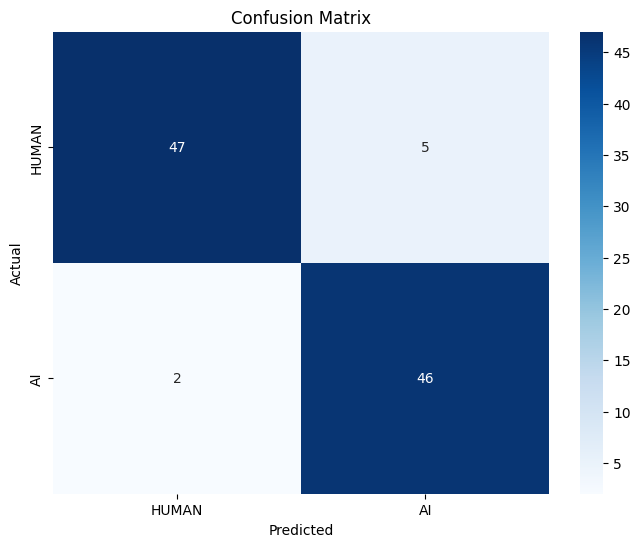

Predictions saved to: test_predictions_indic_bert.csv


In [25]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_indic_bert.csv"
)

####Save model-1

In [26]:
trainer.save_model("./my_finetuned_model_indic_bert_93")
tokenizer.save_pretrained("./my_finetuned_model_indic_bert_93")

('./my_finetuned_model_indic_bert_93/tokenizer_config.json',
 './my_finetuned_model_indic_bert_93/special_tokens_map.json',
 './my_finetuned_model_indic_bert_93/spiece.model',
 './my_finetuned_model_indic_bert_93/added_tokens.json',
 './my_finetuned_model_indic_bert_93/tokenizer.json')

In [27]:
!zip -r /content/my_finetuned_model_indic_bert_93.zip /content/my_finetuned_model_indic_bert_93

  adding: content/my_finetuned_model_indic_bert_93/ (stored 0%)
  adding: content/my_finetuned_model_indic_bert_93/model.safetensors (deflated 7%)
  adding: content/my_finetuned_model_indic_bert_93/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_indic_bert_93/spiece.model (deflated 60%)
  adding: content/my_finetuned_model_indic_bert_93/config.json (deflated 53%)
  adding: content/my_finetuned_model_indic_bert_93/tokenizer_config.json (deflated 74%)
  adding: content/my_finetuned_model_indic_bert_93/special_tokens_map.json (deflated 49%)
  adding: content/my_finetuned_model_indic_bert_93/tokenizer.json (deflated 77%)


In [28]:
from google.colab import files
files.download("/content/my_finetuned_model_indic_bert_93.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Load old AI indic model

In [ ]:
!unzip /content/my_finetuned_model_indic_bert_1.zip

Archive:  /content/my_finetuned_model_indic_bert_1.zip
   creating: content/my_finetuned_model_indic_bert_1/
  inflating: content/my_finetuned_model_indic_bert_1/special_tokens_map.json  
  inflating: content/my_finetuned_model_indic_bert_1/tokenizer_config.json  
  inflating: content/my_finetuned_model_indic_bert_1/config.json  
  inflating: content/my_finetuned_model_indic_bert_1/spiece.model  
  inflating: content/my_finetuned_model_indic_bert_1/model.safetensors  
  inflating: content/my_finetuned_model_indic_bert_1/tokenizer.json  
  inflating: content/my_finetuned_model_indic_bert_1/training_args.bin  


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("/content/my_finetuned_model_indic_bert_1")
tokenizer = AutoTokenizer.from_pretrained("/content/my_finetuned_model_indic_bert_1")

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
)

<ipython-input-35-5038f7fa8d6c>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


###Model___2

####Model-2: XLM

In [29]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [30]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [31]:
train_dataset = TamilDataset(train_encodings, list(train_labels))
val_dataset = TamilDataset(val_encodings, list(val_labels))

In [32]:
model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [33]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-33-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.368492
2,No log,0.369312
3,No log,0.229982


TrainOutput(global_step=123, training_loss=0.35017615217503495, metrics={'train_runtime': 55.8274, 'train_samples_per_second': 34.714, 'train_steps_per_second': 2.203, 'total_flos': 44816240503800.0, 'train_loss': 0.35017615217503495, 'epoch': 3.0})

In [34]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       1.00      0.86      0.92        76
          AI       0.89      1.00      0.94        86

    accuracy                           0.93       162
   macro avg       0.94      0.93      0.93       162
weighted avg       0.94      0.93      0.93       162



####Test Model-2

Accuracy: 0.9400

Classification Report:

              precision    recall  f1-score   support

       HUMAN       1.00      0.88      0.94        52
          AI       0.89      1.00      0.94        48

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.95      0.94      0.94       100



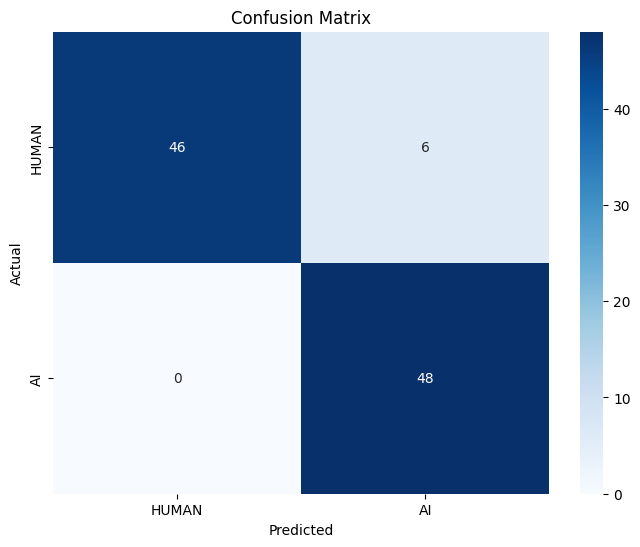

Predictions saved to: test_predictions_xlm.csv


In [35]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_xlm.csv"
)

####Save model-2

In [ ]:
trainer.save_model("./my_finetuned_model_xlm")
tokenizer.save_pretrained("./my_finetuned_model_xlm")

('./my_finetuned_model_xlb/tokenizer_config.json',
 './my_finetuned_model_xlb/special_tokens_map.json',
 './my_finetuned_model_xlb/sentencepiece.bpe.model',
 './my_finetuned_model_xlb/added_tokens.json',
 './my_finetuned_model_xlb/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_xlm.zip /content/my_finetuned_model_xlm

  adding: content/my_finetuned_model_xlb/ (stored 0%)
  adding: content/my_finetuned_model_xlb/model.safetensors (deflated 22%)
  adding: content/my_finetuned_model_xlb/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_xlb/sentencepiece.bpe.model (deflated 49%)
  adding: content/my_finetuned_model_xlb/config.json (deflated 50%)
  adding: content/my_finetuned_model_xlb/tokenizer_config.json (deflated 76%)
  adding: content/my_finetuned_model_xlb/special_tokens_map.json (deflated 52%)
  adding: content/my_finetuned_model_xlb/tokenizer.json (deflated 76%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_xlm.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Model____3

####Model-3:google/muril-base-cased

In [36]:
tokenizer = AutoTokenizer.from_pretrained('google/muril-base-cased')

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

In [37]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [38]:
train_dataset = TamilDataset(train_encodings, list(train_labels))
val_dataset = TamilDataset(val_encodings, list(val_labels))

In [39]:
model = AutoModelForSequenceClassification.from_pretrained('google/muril-base-cased', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-40-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.642459
2,No log,0.552325
3,No log,0.527757


TrainOutput(global_step=123, training_loss=0.6129763223291412, metrics={'train_runtime': 48.8923, 'train_samples_per_second': 39.638, 'train_steps_per_second': 2.516, 'total_flos': 38840741769960.0, 'train_loss': 0.6129763223291412, 'epoch': 3.0})

In [41]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       1.00      0.97      0.99        76
          AI       0.98      1.00      0.99        86

    accuracy                           0.99       162
   macro avg       0.99      0.99      0.99       162
weighted avg       0.99      0.99      0.99       162



####Test Model-3

Accuracy: 0.9400

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.98      0.90      0.94        52
          AI       0.90      0.98      0.94        48

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



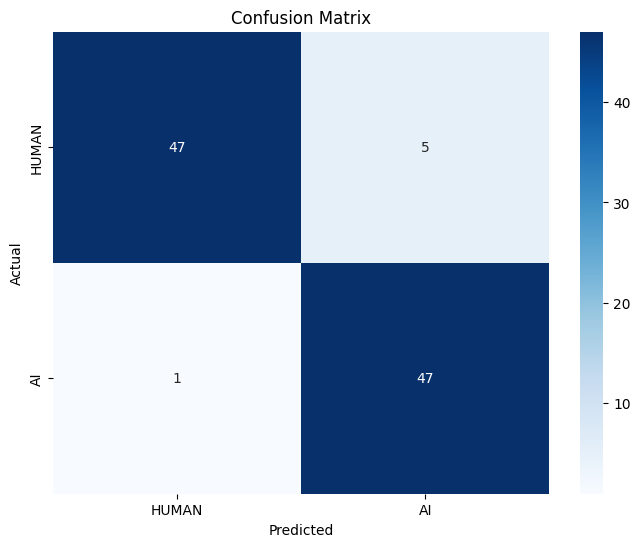

Predictions saved to: test_predictions_MuRIL.csv


In [42]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_MuRIL.csv"
)

####Save Model-3

In [43]:
trainer.save_model("./my_finetuned_model_muril")
tokenizer.save_pretrained("./my_finetuned_model_muril")

('./my_finetuned_model_muril/tokenizer_config.json',
 './my_finetuned_model_muril/special_tokens_map.json',
 './my_finetuned_model_muril/vocab.txt',
 './my_finetuned_model_muril/added_tokens.json',
 './my_finetuned_model_muril/tokenizer.json')

In [44]:
!zip -r /content/my_finetuned_model_xlm.zip /content/my_finetuned_model_muril

  adding: content/my_finetuned_model_muril/ (stored 0%)
  adding: content/my_finetuned_model_muril/model.safetensors (deflated 7%)
  adding: content/my_finetuned_model_muril/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_muril/config.json (deflated 50%)
  adding: content/my_finetuned_model_muril/tokenizer_config.json (deflated 75%)
  adding: content/my_finetuned_model_muril/special_tokens_map.json (deflated 42%)
  adding: content/my_finetuned_model_muril/vocab.txt (deflated 61%)
  adding: content/my_finetuned_model_muril/tokenizer.json (deflated 70%)


In [45]:
from google.colab import files
files.download("/content/my_finetuned_model_xlm.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>